In [ ]:
%pip install sdv

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 203.2/203.2 kB 5.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 140.6/140.6 kB 5.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 14.9/14.9 MB 50.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 52.7/52.7 kB 1.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 74.5/74.5 kB 3.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 202.3/202.3 kB 8.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.0/2.0 MB 48.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 86.8/86.8 kB 3.5 MB/s eta 0:00:00


In [ ]:
!pip install -q plotly==6.1.1 kaleido==1.2.0
!plotly_get_chrome
!sudo apt update && sudo apt-get install libnss3 libatk-bridge2.0-0 libcups2 libxcomposite1 libxdamage1 libxfixes3 libxrandr2 libgbm1 libxkbcommon0 libpango-1.0-0 libcairo2 libasound2

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 16.1/16.1 MB 51.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 69.0/69.0 kB 4.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 49.3/49.3 kB 3.4 MB/s eta 0:00:00
y

Plotly will install a copy of Google Chrome to be used for generating static images of plots.
Chrome will be installed at: /usr/local/lib/python3.12/dist-packages/choreographer/cli/browser_exe
Do you want to proceed? [y/n] y
Installing Chrome for Plotly...
Chrome installed successfully.
The Chrome executable is now located at: /usr/local/lib/python3.12/dist-packages/choreographer/cli/browser_exe/chrome-linux64/chrome
Get:1 https://cli.github.com/packages stable InRelease [3,917 B]
Get:2 https://cloud.r-project.org/bin/linux/ubuntu jammy-cran40/ InRelease [3,632 B]
Get:3 https://cli.github.com/packages stable/main amd64 Packages [357 B]
Get:4 http://security.ubuntu.com/ubuntu jammy-security InRelease [129 kB]
Get:5 https://cloud.r-project.org/bin/linux/

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
import pandas as pd
import numpy as np
from sdv.metadata import Metadata
from sdv.single_table import TVAESynthesizer
from sdv.evaluation.single_table import run_diagnostic, evaluate_quality, get_column_plot, get_column_pair_plot

In [ ]:
data = pd.read_csv('/content/drive/MyDrive/Colab Notebooks/FINALFINAL.csv', sep=';', encoding='latin1')
data.head()

,CASEID,FUELTYPE,WEATHER,SURFCOND,VIN,DVTOTAL,ROLLOVER,SPEEDLIMIT,BODYTYPE,PASSENGERS,BELTED_PASSENGERS,GAD1,AIRBAG_DEPLOYED,FIRE
0,2400023,gasoline,clear,dry,1N6AA1ED2MN5,25,no rollover,56,pickup/light truck,2,2,Front,Deployed,missing
1,2400024,gasoline,rain,wet,WDDSJ4EBXGN3,25,no rollover,80,passenger car,2,2,Front,Deployed,missing
2,2400030,gasoline,snow,snow,5FNYF6H03LB0,999,rollover,129,SUV,5,5,Right Side,Deployed,missing
3,2400035,gasoline,clear,dry,5TFCZ5AN5HX1,999,no rollover,89,pickup/light truck,1,1,Front,Deployed,missing
4,2400042,gasoline,rain,wet,1N4AA6AP4GC4,999,no rollover,113,passenger car,1,0,Unknown,Unknown,missing


In [ ]:
data.columns


Index(['CASEID', 'FUELTYPE', 'WEATHER', 'SURFCOND', 'VIN', 'DVTOTAL',
       'ROLLOVER', 'SPEEDLIMIT', 'BODYTYPE', 'PASSENGERS', 'BELTED_PASSENGERS',
       'GAD1', 'AIRBAG_DEPLOYED', 'FIRE'],
      dtype='object')

In [ ]:
data.shape

(736, 14)

In [ ]:
import numpy as np
data['DVTOTAL'] = pd.to_numeric(data['DVTOTAL'], errors='coerce')
data['DVTOTAL'] = data['DVTOTAL'].replace(999, np.nan)
observed_dvtotal = data['DVTOTAL'].dropna()
data.loc[data['DVTOTAL'].isna(), 'DVTOTAL'] = observed_dvtotal.sample(data['DVTOTAL'].isna().sum(), replace=True).values

data['SPEEDLIMIT'] = pd.to_numeric(data['SPEEDLIMIT'], errors='coerce')
data['SPEEDLIMIT'] = data['SPEEDLIMIT'].replace(999, np.nan)
observed_speedlimit = data['SPEEDLIMIT'].dropna()
data.loc[data['SPEEDLIMIT'].isna(), 'SPEEDLIMIT'] = observed_speedlimit.sample(data['SPEEDLIMIT'].isna().sum(), replace=True).values

In [ ]:
data = data.drop(columns=['CASEID'])
data.head()

,FUELTYPE,WEATHER,SURFCOND,VIN,DVTOTAL,ROLLOVER,SPEEDLIMIT,BODYTYPE,PASSENGERS,BELTED_PASSENGERS,GAD1,AIRBAG_DEPLOYED,FIRE
0,gasoline,clear,dry,1N6AA1ED2MN5,25.0,no rollover,56.0,pickup/light truck,2,2,Front,Deployed,missing
1,gasoline,rain,wet,WDDSJ4EBXGN3,25.0,no rollover,80.0,passenger car,2,2,Front,Deployed,missing
2,gasoline,snow,snow,5FNYF6H03LB0,15.0,rollover,129.0,SUV,5,5,Right Side,Deployed,missing
3,gasoline,clear,dry,5TFCZ5AN5HX1,25.0,no rollover,89.0,pickup/light truck,1,1,Front,Deployed,missing
4,gasoline,rain,wet,1N4AA6AP4GC4,62.0,no rollover,113.0,passenger car,1,0,Unknown,Unknown,missing


In [ ]:
metadata = Metadata.detect_from_dataframe(data=data)
metadata.update_column(column_name='FUELTYPE', table_name='table', sdtype='categorical')
metadata.update_column(column_name='WEATHER', table_name='table', sdtype='categorical')
metadata.update_column(column_name='SURFCOND', table_name='table', sdtype='categorical')
metadata.update_column(column_name='DVTOTAL', table_name='table', sdtype='numerical')
metadata.update_column(column_name='ROLLOVER', table_name='table', sdtype='categorical')
metadata.update_column(column_name='SPEEDLIMIT', table_name='table', sdtype='numerical')
metadata.update_column(column_name='BODYTYPE', table_name='table', sdtype='categorical')
metadata.update_column(column_name='PASSENGERS', table_name='table', sdtype='categorical')
metadata.update_column(column_name='BELTED_PASSENGERS', table_name='table', sdtype='categorical')
metadata.update_column(column_name='GAD1', table_name='table', sdtype='categorical')
metadata.update_column(column_name='AIRBAG_DEPLOYED', table_name='table', sdtype='categorical')
metadata.update_column(column_name='FIRE', table_name='table', sdtype='categorical')
metadata

{
    "tables": {
        "table": {
            "columns": {
                "FUELTYPE": {
                    "sdtype": "categorical"
                },
                "WEATHER": {
                    "sdtype": "categorical"
                },
                "SURFCOND": {
                    "sdtype": "categorical"
                },
                "VIN": {
                    "pii": true,
                    "sdtype": "vin"
                },
                "DVTOTAL": {
                    "sdtype": "numerical"
                },
                "ROLLOVER": {
                    "sdtype": "categorical"
                },
                "SPEEDLIMIT": {
                    "sdtype": "numerical"
                },
                "BODYTYPE": {
                    "sdtype": "categorical"
                },
                "PASSENGERS": {
                    "sdtype": "categorical"
                },
                "BELTED_PASSENGERS": {
                    "sdtype": "categorical"


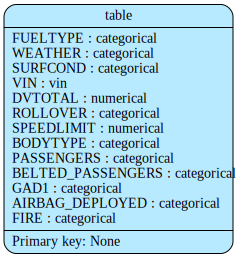

In [ ]:
metadata.visualize()

In [ ]:
synthesizer = TVAESynthesizer(
    metadata, # require
    enforce_min_max_values=False,
    enforce_rounding=True,

    epochs=500
)

/usr/local/lib/python3.12/dist-packages/sdv/single_table/base.py:134: UserWarning:

We strongly recommend saving the metadata using 'save_to_json' for replicability in future SDV versions.



In [ ]:
synthesizer.fit(data)
synthetic_data = synthesizer.sample(num_rows=len(data))

In [ ]:

synthetic_data = synthesizer.sample(num_rows=len(data))
synthetic_data


,FUELTYPE,WEATHER,SURFCOND,VIN,DVTOTAL,ROLLOVER,SPEEDLIMIT,BODYTYPE,PASSENGERS,BELTED_PASSENGERS,GAD1,AIRBAG_DEPLOYED,FIRE
0,gasoline,clear,dry,K21SHFNB1L9GJ1807,12.0,no rollover,56.0,passenger car,1,0,Front,Not deployed/not available,missing
1,gasoline,rain,dry,4L09D0XA14NT27834,44.0,no rollover,101.0,passenger car,2,1,Front,Deployed,missing
2,gasoline,clear,dry,8UFUA80Y31KHV5267,45.0,unknown,52.0,passenger car,1,0,Front,Deployed,missing
3,gasoline,clear,dry,Y5U43VT5881AZ3434,39.0,no rollover,61.0,SUV,1,0,Front,Deployed,missing
4,gasoline,clear,dry,TMEEUCTS240J31853,21.0,no rollover,96.0,pickup/light truck,1,0,Front,Unknown,missing
...,...,...,...,...,...,...,...,...,...,...,...,...,...
731,gasoline,clear,dry,7FX7ND976ZGYS4136,21.0,no rollover,73.0,passenger car,2,2,Front,Deployed,missing
732,gasoline,clear,dry,06BU981V2LTY29999,9.0,no rollover,40.0,SUV,2,1,Front,Deployed,missing
733,gasoline,clear,dry,NWX5VS7L14ZT52531,2.0,unknown,44.0,SUV,1,0,Front,Unknown,missing
734,gasoline,clear,dry,XR0SGH5H29HZ88365,20.0,no rollover,38.0,SUV,1,1,Front,Deployed,missing


In [ ]:
columns = [
    'FUELTYPE',
    'WEATHER',
    'SURFCOND',
    'VIN',
    'DVTOTAL',
    'ROLLOVER',
    'SPEEDLIMIT',
    'BODYTYPE',
    'PASSENGERS',
    'BELTED_PASSENGERS',
    'GAD1',
    'AIRBAG_DEPLOYED',
    'FIRE'
]

for col in columns:
    print(f'\n--- {col} ---')
    display(
        pd.DataFrame({
            'Real': data[col].value_counts(),
            'Synthetic': synthetic_data[col].value_counts()
        }).fillna(0)
    )


--- FUELTYPE ---


,Real,Synthetic
FUELTYPE,,
diesel,15,0.0
gasoline,693,736.0
gasoline/ethanol,21,0.0
gasoline/lithium (elbil),7,0.0



--- WEATHER ---


,Real,Synthetic
WEATHER,,
clear,564,715.0
cloudy,64,12.0
rain,68,5.0
snow,20,4.0
unknown,20,0.0



--- SURFCOND ---


...

,Real,Synthetic
GAD1,,
Back/Truck Back,8,0.0
Front,573,730.0
Left Side,36,1.0
Noncollision,6,0.0
Right Side,37,1.0
Top,53,3.0
Undercarriage,11,0.0
Unknown,12,1.0



--- AIRBAG_DEPLOYED ---


,Real,Synthetic
AIRBAG_DEPLOYED,,
Deployed,375,407
Not deployed/not available,254,248
Unknown,107,81



--- FIRE ---


,Real,Synthetic
FIRE,,
fire,2,0.0
missing,731,736.0
no fire,3,0.0


In [ ]:
from sdv.evaluation.single_table import run_diagnostic, evaluate_quality

In [ ]:
diagnostic = run_diagnostic(
    real_data=data,
    synthetic_data=synthetic_data,
    metadata=metadata
)

Generating report ...

(1/2) Evaluating Data Validity: |██████████| 13/13 [00:00<00:00, 766.03it/s]|
Data Validity Score: 99.99%

(2/2) Evaluating Data Structure: |██████████| 1/1 [00:00<00:00, 191.56it/s]|
Data Structure Score: 100.0%

Overall Score (Average): 99.99%



In [ ]:
diagnostic.get_score()

np.float64(0.9999433876811594)

In [ ]:
quality_report = evaluate_quality(
    real_data=data,
    synthetic_data=synthetic_data,
    metadata=metadata
)

Generating report ...

(1/2) Evaluating Column Shapes: |██████████| 13/13 [00:00<00:00, 766.24it/s]|
Column Shapes Score: 88.73%

(2/2) Evaluating Column Pair Trends: |██████████| 78/78 [00:00<00:00, 265.23it/s]|
Column Pair Trends Score: 94.02%

Overall Score (Average): 91.38%



In [ ]:
quality_report.get_score()

np.float64(0.91376182568438)

In [ ]:
diagnostic.get_details(property_name='Data Validity')

,Column,Metric,Score
0,FUELTYPE,CategoryAdherence,1.000000
1,WEATHER,CategoryAdherence,1.000000
2,SURFCOND,CategoryAdherence,1.000000
3,DVTOTAL,BoundaryAdherence,0.998641
4,ROLLOVER,CategoryAdherence,1.000000
5,SPEEDLIMIT,BoundaryAdherence,1.000000
6,BODYTYPE,CategoryAdherence,1.000000
7,PASSENGERS,CategoryAdherence,1.000000
8,BELTED_PASSENGERS,CategoryAdherence,1.000000
9,GAD1,CategoryAdherence,1.000000


In [ ]:
quality_report.get_details(property_name='Column Shapes')

,Column,Metric,Score
0,FUELTYPE,TVComplement,0.941576
1,WEATHER,TVComplement,0.794837
2,SURFCOND,TVComplement,0.793478
3,DVTOTAL,KSComplement,0.860054
4,ROLLOVER,TVComplement,0.873641
5,SPEEDLIMIT,KSComplement,0.865489
6,BODYTYPE,TVComplement,0.870501
7,PASSENGERS,TVComplement,0.953804
8,BELTED_PASSENGERS,TVComplement,0.957880
9,GAD1,TVComplement,0.786685


In [ ]:
quality_report.get_details(property_name='Column Pair Trends')

,Column 1,Column 2,Metric,Score,Real Correlation,Synthetic Correlation,Real Association,Meets Threshold?
0,FUELTYPE,WEATHER,ContingencySimilarity,NaN,NaN,NaN,0.106304,False
1,FUELTYPE,SURFCOND,ContingencySimilarity,NaN,NaN,NaN,0.125589,False
2,FUELTYPE,DVTOTAL,ContingencySimilarity,NaN,NaN,NaN,0.117198,False
3,FUELTYPE,ROLLOVER,ContingencySimilarity,NaN,NaN,NaN,0.052934,False
4,FUELTYPE,SPEEDLIMIT,ContingencySimilarity,NaN,NaN,NaN,0.136498,False
...,...,...,...,...,...,...,...,...
61,BELTED_PASSENGERS,AIRBAG_DEPLOYED,ContingencySimilarity,NaN,NaN,NaN,0.275610,False
62,BELTED_PASSENGERS,FIRE,ContingencySimilarity,NaN,NaN,NaN,0.035446,False
63,GAD1,AIRBAG_DEPLOYED,ContingencySimilarity,NaN,NaN,NaN,0.256907,False
64,GAD1,FIRE,ContingencySimilarity,NaN,NaN,NaN,0.176186,False


In [ ]:
import pandas as pd
import numpy as np

real = data.copy()
syn = synthetic_data.copy()

categorical_cols = [
    'FUELTYPE',
    'WEATHER',
    'SURFCOND',
    'ROLLOVER',
    'BODYTYPE',
    'PASSENGERS',
    'BELTED_PASSENGERS',
    'GAD1',
    'AIRBAG_DEPLOYED',
    'FIRE'
]

numerical_cols = [
    'DVTOTAL',
    'SPEEDLIMIT'
]

all_cols = categorical_cols + numerical_cols

real = real[all_cols].copy()
syn = syn[all_cols].copy()

for col in categorical_cols:
    real[col] = real[col].astype(str)
    syn[col] = syn[col].astype(str)

for col in numerical_cols:
    real[col] = pd.to_numeric(real[col], errors='coerce')
    syn[col] = pd.to_numeric(syn[col], errors='coerce')

In [ ]:
from scipy.stats import wasserstein_distance

wasserstein_results = []

for col in numerical_cols:
    r = real[col].dropna()
    s = syn[col].dropna()
    score = wasserstein_distance(r, s)
    wasserstein_results.append({
        "Variable": col,
        "Wasserstein Distance": score
    })

wasserstein_df = pd.DataFrame(wasserstein_results)
wasserstein_df

,Variable,Wasserstein Distance
0,DVTOTAL,5.277174
1,SPEEDLIMIT,3.675272


In [ ]:
from scipy.spatial.distance import jensenshannon

js_results = []

for col in categorical_cols:
    real_counts = real[col].value_counts(normalize=True)
    syn_counts = syn[col].value_counts(normalize=True)
    categories = sorted(set(real_counts.index).union(set(syn_counts.index)))

    p = real_counts.reindex(categories, fill_value=0).values
    q = syn_counts.reindex(categories, fill_value=0).values

    score = jensenshannon(p, q) ** 2

    js_results.append({
        "Variable": col,
        "Jensen-Shannon Divergence": score
    })

js_df = pd.DataFrame(js_results)
js_df

,Variable,Jensen-Shannon Divergence
0,FUELTYPE,0.020688
1,WEATHER,0.054701
2,SURFCOND,0.035993
3,ROLLOVER,0.014851
4,BODYTYPE,0.027343
5,PASSENGERS,0.008077
6,BELTED_PASSENGERS,0.006748
7,GAD1,0.069414
8,AIRBAG_DEPLOYED,0.001695
9,FIRE,0.002360


In [ ]:
encoded_real = pd.get_dummies(real, columns=categorical_cols, dummy_na=False)
encoded_syn = pd.get_dummies(syn, columns=categorical_cols, dummy_na=False)

encoded_real, encoded_syn = encoded_real.align(encoded_syn, join='outer', axis=1, fill_value=0)

real_corr = encoded_real.corr().fillna(0)
syn_corr = encoded_syn.corr().fillna(0)

corr_diff = np.abs(real_corr - syn_corr)

mean_corr_difference = corr_diff.values.mean()

mean_corr_difference

np.float64(0.04864507810071754)

In [ ]:
from sklearn.metrics import mutual_info_score

mi_results = []

for col1 in all_cols:
    for col2 in all_cols:
        if col1 < col2:
            r1 = real[col1].astype(str)
            r2 = real[col2].astype(str)
            s1 = syn[col1].astype(str)
            s2 = syn[col2].astype(str)

            real_mi = mutual_info_score(r1, r2)
            syn_mi = mutual_info_score(s1, s2)

            mi_results.append({
                "Variable 1": col1,
                "Variable 2": col2,
                "Real MI": real_mi,
                "Synthetic MI": syn_mi,
                "Absolute Difference": abs(real_mi - syn_mi)
            })

mi_df = pd.DataFrame(mi_results)
mi_df.sort_values("Absolute Difference", ascending=False).head(15)

,Variable 1,Variable 2,Real MI,Synthetic MI,Absolute Difference
63,DVTOTAL,SPEEDLIMIT,0.377009,1.305209,0.928200
48,AIRBAG_DEPLOYED,SPEEDLIMIT,0.022939,0.201052,0.178112
61,DVTOTAL,GAD1,0.196589,0.027764,0.168824
32,BELTED_PASSENGERS,SPEEDLIMIT,0.046621,0.181698,0.135077
18,BODYTYPE,SPEEDLIMIT,0.060865,0.159776,0.098910
22,PASSENGERS,SPEEDLIMIT,0.046415,0.131958,0.085543
56,DVTOTAL,FUELTYPE,0.071433,0.000000,0.071433
65,SPEEDLIMIT,SURFCOND,0.071964,0.140122,0.068158
28,BELTED_PASSENGERS,PASSENGERS,0.367095,0.305829,0.061265
57,DVTOTAL,WEATHER,0.124145,0.064858,0.059287


In [ ]:
constraint_results = {}

if "PASSENGERS" in real.columns and "BELTED_PASSENGERS" in real.columns:
    real_pass = pd.to_numeric(real["PASSENGERS"], errors="coerce")
    real_belt = pd.to_numeric(real["BELTED_PASSENGERS"], errors="coerce")
    syn_pass = pd.to_numeric(syn["PASSENGERS"], errors="coerce")
    syn_belt = pd.to_numeric(syn["BELTED_PASSENGERS"], errors="coerce")

    real_valid = (real_belt <= real_pass).mean()
    syn_valid = (syn_belt <= syn_pass).mean()

    constraint_results["BELTED_PASSENGERS <= PASSENGERS"] = {
        "Real Validity": real_valid,
        "Synthetic Validity": syn_valid
    }

for col in ["DVTOTAL", "SPEEDLIMIT"]:
    if col in real.columns:
        real_valid = (pd.to_numeric(real[col], errors="coerce") >= 0).mean()
        syn_valid = (pd.to_numeric(syn[col], errors="coerce") >= 0).mean()

        constraint_results[f"{col} >= 0"] = {
            "Real Validity": real_valid,
            "Synthetic Validity": syn_valid
        }

constraint_df = pd.DataFrame(constraint_results).T
constraint_df

,Real Validity,Synthetic Validity
BELTED_PASSENGERS <= PASSENGERS,1.0,1.000000
DVTOTAL >= 0,1.0,0.998641
SPEEDLIMIT >= 0,1.0,1.000000


In [ ]:
real_rows = real.astype(str).apply(lambda row: "|".join(row.values), axis=1)
syn_rows = syn.astype(str).apply(lambda row: "|".join(row.values), axis=1)

duplicate_rate = syn_rows.isin(real_rows).mean()

duplicate_rate

np.float64(0.006793478260869565)

In [ ]:
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.compose import ColumnTransformer
from sklearn.neighbors import NearestNeighbors
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer

preprocessor = ColumnTransformer(
    transformers=[
        ("num", Pipeline([
            ("imputer", SimpleImputer(strategy="median")),
            ("scaler", StandardScaler())
        ]), numerical_cols),
        ("cat", Pipeline([
            ("imputer", SimpleImputer(strategy="most_frequent")),
            ("encoder", OneHotEncoder(handle_unknown="ignore"))
        ]), categorical_cols)
    ]
)

combined = pd.concat([real, syn], axis=0)

preprocessor.fit(combined)

real_encoded = preprocessor.transform(real)
syn_encoded = preprocessor.transform(syn)

nn = NearestNeighbors(n_neighbors=1)
nn.fit(real_encoded)

distances, indices = nn.kneighbors(syn_encoded)

nearest_neighbor_mean = distances.mean()
nearest_neighbor_min = distances.min()

nearest_neighbor_mean, nearest_neighbor_min

(np.float64(0.6366164146572342), np.float64(0.0))

In [ ]:
from sklearn.base import clone

real_model = Pipeline([
    ("preprocessor", clone(preprocessor_ml)),
    ("classifier", RandomForestClassifier(random_state=42))
])

synthetic_model = Pipeline([
    ("preprocessor", clone(preprocessor_ml)),
    ("classifier", RandomForestClassifier(random_state=42))
])

real_model.fit(X_train_real, y_train_real)
synthetic_model.fit(X_syn, y_syn)

real_pred = real_model.predict(X_test_real)
synthetic_pred = synthetic_model.predict(X_test_real)

ml_utility_results = pd.DataFrame([
    {
        "Training Data": "Real",
        "Test Data": "Real",
        "Accuracy": accuracy_score(y_test_real, real_pred),
        "F1 Macro": f1_score(y_test_real, real_pred, average="macro", zero_division=0)
    },
    {
        "Training Data": "Synthetic",
        "Test Data": "Real",
        "Accuracy": accuracy_score(y_test_real, synthetic_pred),
        "F1 Macro": f1_score(y_test_real, synthetic_pred, average="macro", zero_division=0)
    }
])

ml_utility_results

,Training Data,Test Data,Accuracy,F1 Macro
0,Real,Real,0.493213,0.450806
1,Synthetic,Real,0.529412,0.457165


In [ ]:
summary_metrics = pd.DataFrame([
    {
        "Metric": "Mean Wasserstein Distance",
        "Value": wasserstein_df["Wasserstein Distance"].mean(),
        "Interpretation": "Lower is better"
    },
    {
        "Metric": "Mean Jensen-Shannon Divergence",
        "Value": js_df["Jensen-Shannon Divergence"].mean(),
        "Interpretation": "Lower is better"
    },
    {
        "Metric": "Mean Correlation Difference",
        "Value": mean_corr_difference,
        "Interpretation": "Lower is better"
    },
    {
        "Metric": "Mean Mutual Information Difference",
        "Value": mi_df["Absolute Difference"].mean(),
        "Interpretation": "Lower is better"
    },
    {
        "Metric": "Duplicate Rate",
        "Value": duplicate_rate,
        "Interpretation": "Lower is better"
    },
    {
        "Metric": "Nearest Neighbor Mean Distance",
        "Value": nearest_neighbor_mean,
        "Interpretation": "Higher may indicate less memorization"
    }
])

summary_metrics

,Metric,Value,Interpretation
0,Mean Wasserstein Distance,4.476223,Lower is better
1,Mean Jensen-Shannon Divergence,0.024187,Lower is better
2,Mean Correlation Difference,0.048645,Lower is better
3,Mean Mutual Information Difference,0.040100,Lower is better
4,Duplicate Rate,0.006793,Lower is better
5,Nearest Neighbor Mean Distance,0.636616,Higher may indicate less memorization


In [ ]:
from sdv.evaluation.single_table import get_column_plot

In [ ]:
save_path = "/content/drive/MyDrive/Colab Notebooks/results/plots_TVAE"

In [ ]:
from sdv.evaluation.single_table import get_column_plot
import matplotlib.pyplot as plt
import os

os.makedirs(save_path, exist_ok=True)

columns = [
    'FUELTYPE',
    'WEATHER',
    'SURFCOND',
    'DVTOTAL',
    'ROLLOVER',
    'SPEEDLIMIT',
    'BODYTYPE',
    'PASSENGERS',
    'BELTED_PASSENGERS',
    'GAD1',
    'AIRBAG_DEPLOYED',
    'FIRE'
]

for col in columns:
    fig = get_column_plot(
        real_data=data,
        synthetic_data=synthetic_data,
        column_name=col,
        metadata=metadata
    )

    img_bytes = fig.to_image(format="png", scale=2)

    with open(f"{save_path}/{col}.png", "wb") as f:
        f.write(img_bytes)

    fig.show()

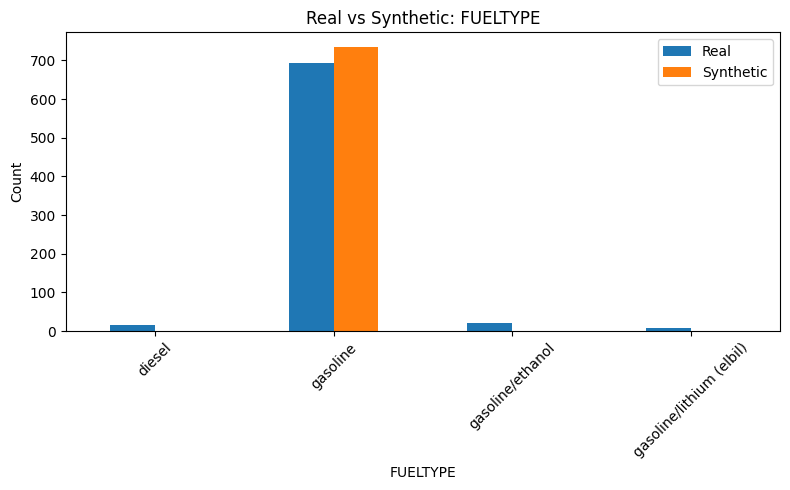

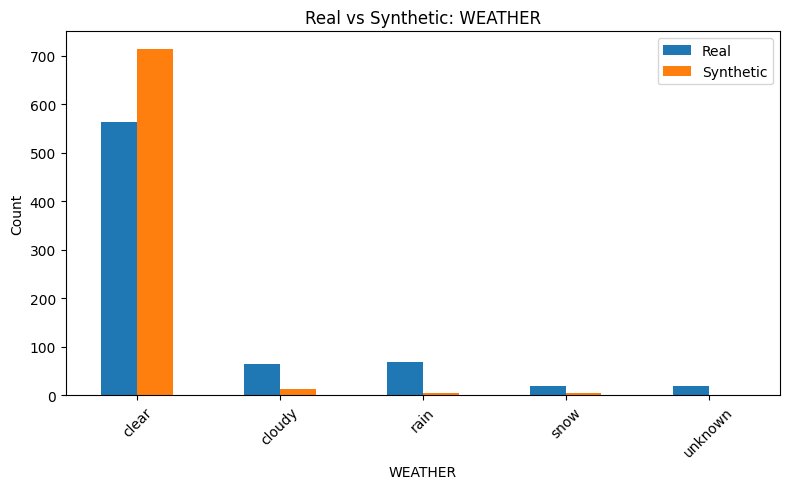

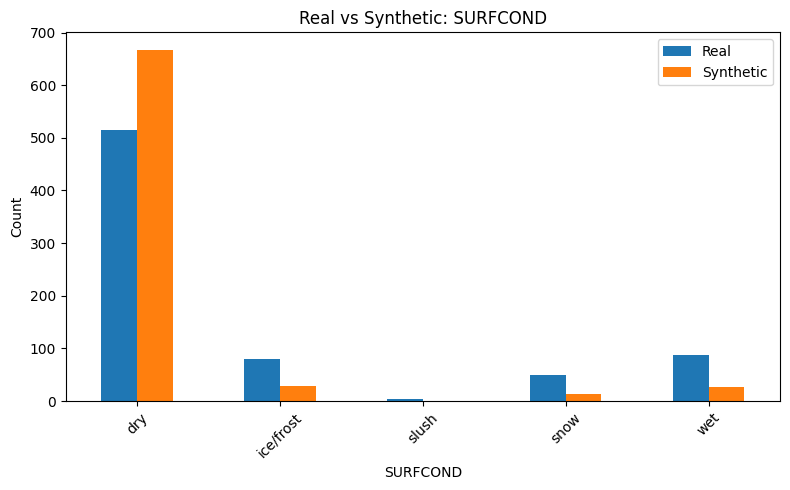

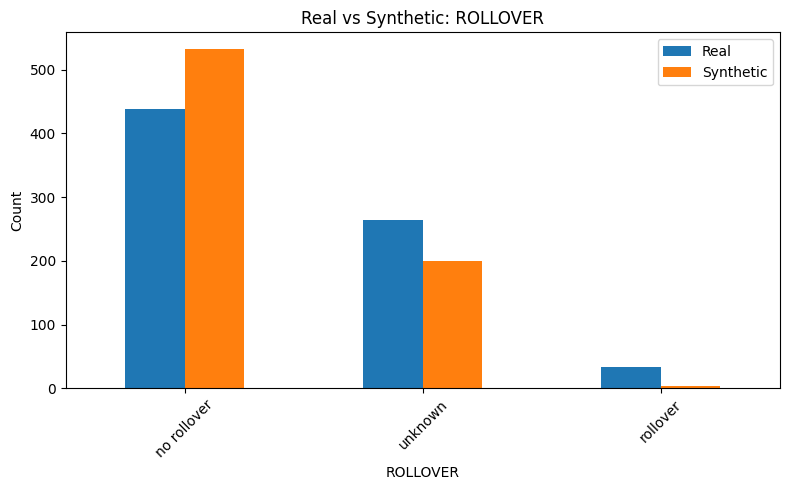

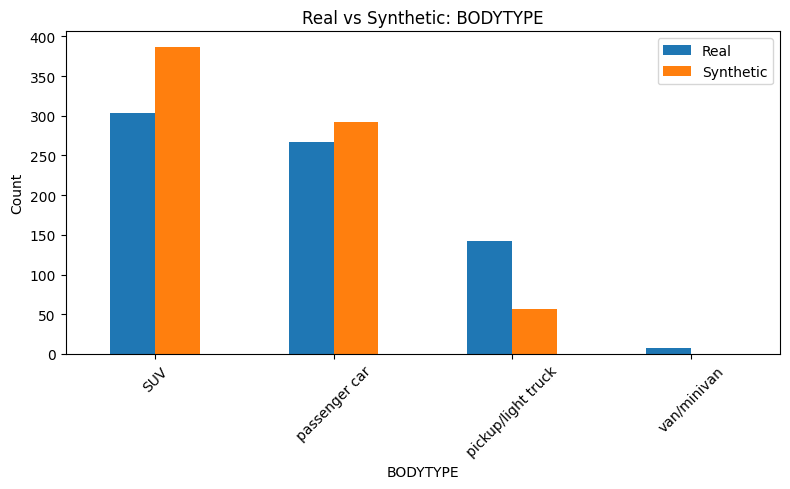

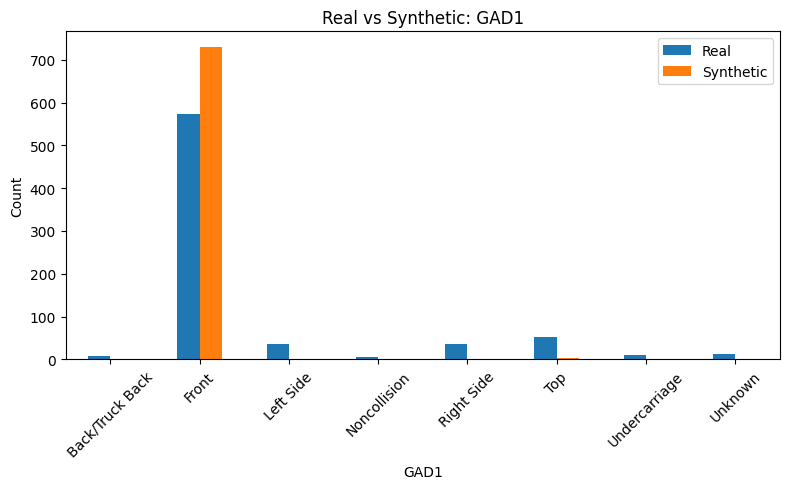

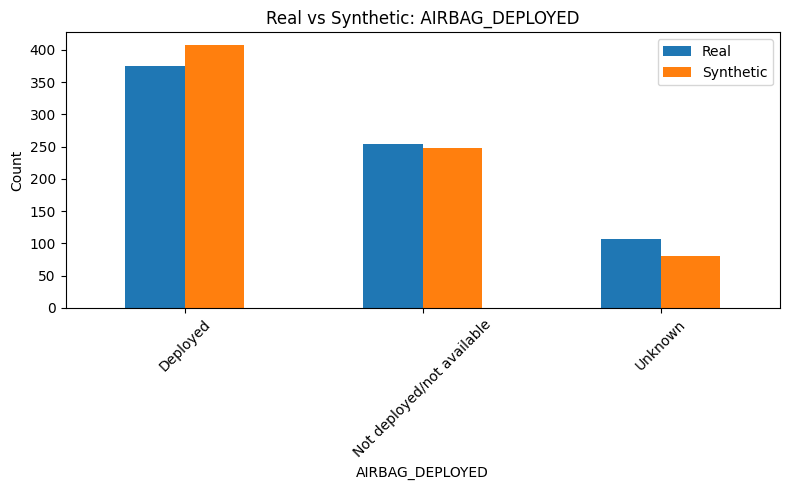

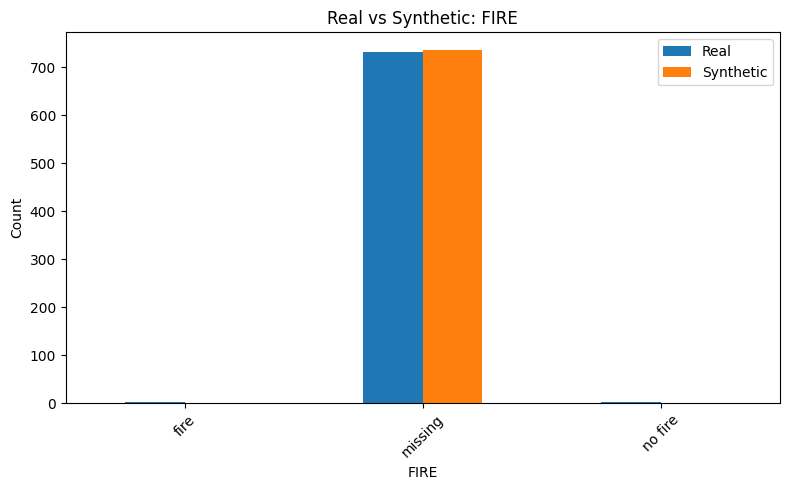

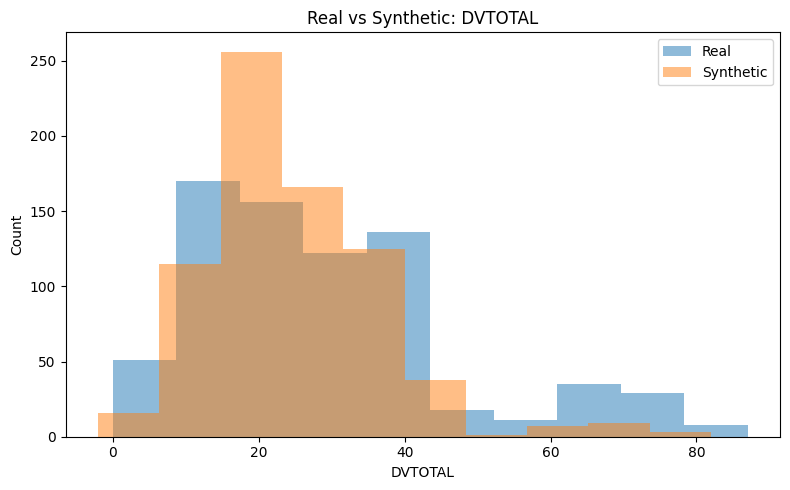

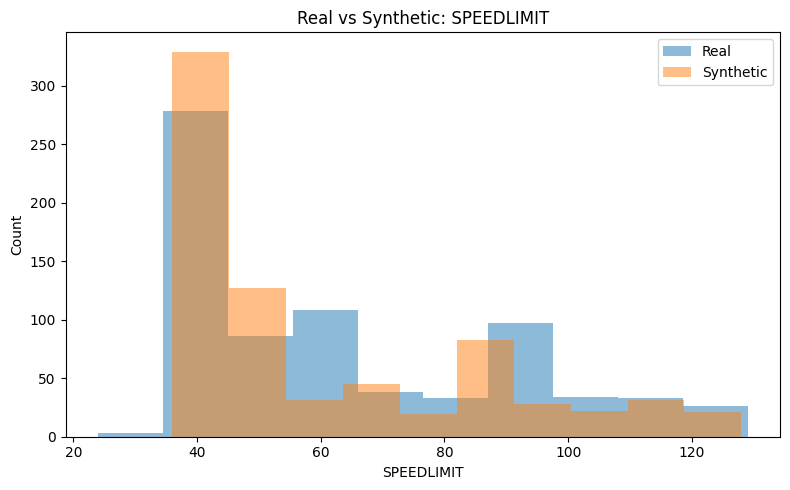

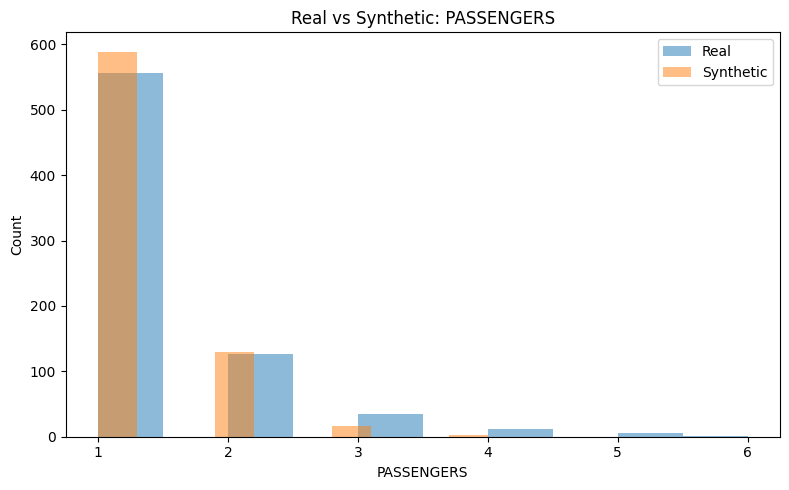

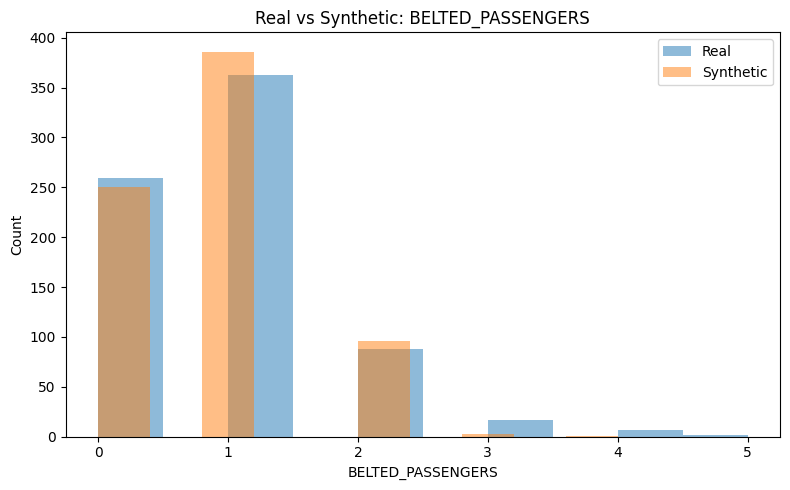

In [ ]:
import matplotlib.pyplot as plt
import pandas as pd

categorical_columns = [
    'FUELTYPE',
    'WEATHER',
    'SURFCOND',
    'ROLLOVER',
    'BODYTYPE',
    'GAD1',
    'AIRBAG_DEPLOYED',
    'FIRE'
]

numerical_columns = [
    'DVTOTAL',
    'SPEEDLIMIT',
    'PASSENGERS',
    'BELTED_PASSENGERS'
]

for col in categorical_columns:
    counts_df = pd.DataFrame({
        'Real': data[col].value_counts(),
        'Synthetic': synthetic_data[col].value_counts()
    }).fillna(0)

    counts_df.plot(kind='bar', figsize=(8,5))
    plt.xlabel(col)
    plt.ylabel('Count')
    plt.title(f'Real vs Synthetic: {col}')
    plt.xticks(rotation=45)
    plt.tight_layout()
    plt.show()

for col in numerical_columns:
    plt.figure(figsize=(8,5))
    plt.hist(pd.to_numeric(data[col], errors='coerce').dropna(), alpha=0.5, label='Real')
    plt.hist(pd.to_numeric(synthetic_data[col], errors='coerce').dropna(), alpha=0.5, label='Synthetic')
    plt.xlabel(col)
    plt.ylabel('Count')
    plt.title(f'Real vs Synthetic: {col}')
    plt.legend()
    plt.tight_layout()
    plt.show()

In [ ]:
from sdv.evaluation.single_table import get_column_pair_plot
import os

save_path = "/content/drive/MyDrive/Colab Notebooks/results/plots_TVAE_compare"
os.makedirs(save_path, exist_ok=True)

pairs = [
    ['DVTOTAL', 'AIRBAG_DEPLOYED'],
    ['DVTOTAL', 'ROLLOVER'],
    ['PASSENGERS', 'BELTED_PASSENGERS'],
    ['WEATHER', 'SURFCOND'],
    ['SPEEDLIMIT', 'DVTOTAL'],
    ['BODYTYPE', 'ROLLOVER'],
    ['SURFCOND', 'ROLLOVER'],
    ['DVTOTAL', 'FIRE']
]

for pair in pairs:
    fig = get_column_pair_plot(
        real_data=data,
        synthetic_data=synthetic_data,
        column_names=pair,
        metadata=metadata
    )

    fig.update_layout(
        title=f"Real vs Synthetic: {pair[0]} vs {pair[1]}",
        title_x=0.5,
        width=950,
        height=600,
        template='plotly_white'
    )

    filename = f"{pair[0]}_{pair[1]}.png"

    img_bytes = fig.to_image(format="png")

    with open(f"{save_path}/{filename}", "wb") as f:
        f.write(img_bytes)

    fig.show()

In [ ]:
import numpy as np
import pandas as pd

synthetic_data["DVTOTAL"] = pd.to_numeric(synthetic_data["DVTOTAL"], errors="coerce").replace(999, np.nan)
synthetic_data["SPEEDLIMIT"] = pd.to_numeric(synthetic_data["SPEEDLIMIT"], errors="coerce").replace(999, np.nan)

In [ ]:
import json
import pandas as pd
import numpy as np

synthetic_data["DVTOTAL"] = pd.to_numeric(synthetic_data["DVTOTAL"], errors="coerce").replace(999, np.nan)
synthetic_data["SPEEDLIMIT"] = pd.to_numeric(synthetic_data["SPEEDLIMIT"], errors="coerce").replace(999, np.nan)

weather_map = {
    0: "Missing",
    1: "Clear",
    2: "Rain",
    3: "Sleet/Hail",
    4: "Snow",
    5: "Smoke/Fog",
    6: "Strong crosswind",
    8: "Cloudy",
    9: "Blowing snow",
    10: "Freezing rain"
}

rollover_map = {
    0: "Unknown",
    1: "No rollover",
    2: "Rollover"
}

surfcond_map = {
    0: "Missing",
    1: "Dry",
    2: "Wet",
    3: "Snow",
    4: "Slush",
    5: "Ice/Frost",
    6: "Water",
    8: "Gravel/Dirt"
}

bodytype_map = {
    1: "Passenger car",
    2: "SUV",
    3: "Pickup/Light truck",
    4: "Van/Minivan"
}

airbag_map = {
    0: "Unknown",
    1: "Deployed",
    2: "Not deployed/Not available"
}

fire_map = {
    0: "Missing",
    1: "No fire",
    2: "Fire",
    9: "Unknown"
}

fueltype_map = {
    1: "Gasoline",
    2: "Gasoline/Ethanol",
    4: "Diesel",
    11: "Gasoline/Lithium electric"
}

gad1_map = {
    "B": "Back/Truck Back",
    "C": "Rear of cab",
    "D": "Back (rear of tractor)",
    "F": "Front",
    "L": "Left Side",
    "N": "Noncollision",
    "R": "Right Side",
    "T": "Top",
    "U": "Undercarriage",
    "V": "Front of cargo area",
    "9": "Unknown"
}

code_system = "https://github.com/scubaduber/Kandidatarbete/blob/main/fhir/CodeSystem/crash-data.json"
patient_identifier_system = "https://scubaduber.github.io/Kandidatarbete/fhir/NamingSystem/synthetic-patient-id"

def get_text(value, mapping):
    if pd.isna(value):
        return "Unknown"
    numeric_value = pd.to_numeric(value, errors="coerce")
    if not pd.isna(numeric_value):
        return mapping.get(int(numeric_value), "Unknown")
    text_value = str(value).strip()
    return mapping.get(text_value, text_value)

def sanitize_code(text):
    return (
        str(text)
        .strip()
        .lower()
        .replace(" ", "-")
        .replace("/", "-")
        .replace("(", "")
        .replace(")", "")
        .replace(",", "")
    )

def make_code(label, code):
    return {
        "coding": [
            {
                "system": code_system,
                "code": code,
                "display": label
            }
        ],
        "text": label
    }

def make_value_codeable(text_value, value_code):
    return {
        "coding": [
            {
                "system": code_system,
                "code": value_code,
                "display": text_value
            }
        ],
        "text": text_value
    }

def add_codeable_observation(entry_list, patient_id, encounter_id, obs_id, label, obs_code, text_value):
    value_code = sanitize_code(text_value)
    entry_list.append(
        {
            "fullUrl": f"urn:uuid:{obs_id}",
            "resource": {
                "resourceType": "Observation",
                "id": obs_id,
                "status": "final",
                "code": make_code(label, obs_code),
                "valueCodeableConcept": make_value_codeable(text_value, value_code),
                "subject": {"reference": f"urn:uuid:{patient_id}"},
                "encounter": {"reference": f"urn:uuid:{encounter_id}"}
            }
        }
    )

def add_quantity_observation(entry_list, patient_id, encounter_id, obs_id, label, obs_code, value, unit=None):
    value_quantity = {"value": None if pd.isna(value) else float(value)}
    if unit is not None:
        value_quantity["unit"] = unit

    entry_list.append(
        {
            "fullUrl": f"urn:uuid:{obs_id}",
            "resource": {
                "resourceType": "Observation",
                "id": obs_id,
                "status": "final",
                "code": make_code(label, obs_code),
                "valueQuantity": value_quantity,
                "subject": {"reference": f"urn:uuid:{patient_id}"},
                "encounter": {"reference": f"urn:uuid:{encounter_id}"}
            }
        }
    )

def add_integer_observation(entry_list, patient_id, encounter_id, obs_id, label, obs_code, value, unknown_codes=None):
    numeric_value = pd.to_numeric(value, errors="coerce")
    if pd.isna(numeric_value):
        final_value = None
    elif unknown_codes is not None and int(numeric_value) in unknown_codes:
        final_value = None
    else:
        final_value = int(numeric_value)

    entry_list.append(
        {
            "fullUrl": f"urn:uuid:{obs_id}",
            "resource": {
                "resourceType": "Observation",
                "id": obs_id,
                "status": "final",
                "code": make_code(label, obs_code),
                "valueInteger": final_value,
                "subject": {"reference": f"urn:uuid:{patient_id}"},
                "encounter": {"reference": f"urn:uuid:{encounter_id}"}
            }
        }
    )

def row_to_fhir_entries(row):
    patient_id = f"patient-{row.name}"
    encounter_id = f"encounter-{row.name}"

    entries = [
        {
            "fullUrl": f"urn:uuid:{patient_id}",
            "resource": {
                "resourceType": "Patient",
                "id": patient_id,
                "identifier": [
                    {
                        "system": patient_identifier_system,
                        "value": patient_id
                    }
                ]
            }
        },
        {
            "fullUrl": f"urn:uuid:{encounter_id}",
            "resource": {
                "resourceType": "Encounter",
                "id": encounter_id,
                "status": "finished",
                "subject": {
                    "reference": f"urn:uuid:{patient_id}"
                }
            }
        }
    ]

    add_quantity_observation(entries, patient_id, encounter_id, f"dvtotal-{row.name}", "Delta-V total", "dvtotal", row["DVTOTAL"], "deltaV")
    add_quantity_observation(entries, patient_id, encounter_id, f"speedlimit-{row.name}", "Speed limit", "speed-limit", row["SPEEDLIMIT"], "mph")

    add_codeable_observation(entries, patient_id, encounter_id, f"weather-{row.name}", "Weather", "weather", get_text(row["WEATHER"], weather_map))
    add_codeable_observation(entries, patient_id, encounter_id, f"rollover-{row.name}", "Rollover", "rollover", get_text(row["ROLLOVER"], rollover_map))
    add_codeable_observation(entries, patient_id, encounter_id, f"surfcond-{row.name}", "Surface condition", "surface-condition", get_text(row["SURFCOND"], surfcond_map))
    add_codeable_observation(entries, patient_id, encounter_id, f"bodytype-{row.name}", "Body type", "body-type", get_text(row["BODYTYPE"], bodytype_map))
    add_codeable_observation(entries, patient_id, encounter_id, f"airbag-{row.name}", "Airbag deployed", "airbag-deployed", get_text(row["AIRBAG_DEPLOYED"], airbag_map))
    add_codeable_observation(entries, patient_id, encounter_id, f"fire-{row.name}", "Fire", "fire", get_text(row["FIRE"], fire_map))
    add_codeable_observation(entries, patient_id, encounter_id, f"fueltype-{row.name}", "Fuel type", "fuel-type", get_text(row["FUELTYPE"], fueltype_map))
    add_codeable_observation(entries, patient_id, encounter_id, f"gad1-{row.name}", "General area of damage", "general-area-of-damage", get_text(row["GAD1"], gad1_map))

    add_integer_observation(
        entries,
        patient_id,
        encounter_id,
        f"passengers-{row.name}",
        "Passengers",
        "passengers",
        row["PASSENGERS"],
        unknown_codes={0}
    )

    add_integer_observation(
        entries,
        patient_id,
        encounter_id,
        f"belted-passengers-{row.name}",
        "Belted passengers",
        "belted-passengers",
        row["BELTED_PASSENGERS"],
        unknown_codes={99}
    )

    provenance_id = f"provenance-{row.name}"
    entries.append(
        {
            "fullUrl": f"urn:uuid:{provenance_id}",
            "resource": {
                "resourceType": "Provenance",
                "id": provenance_id,
                "target": [
                    {"reference": f"urn:uuid:{patient_id}"},
                    {"reference": f"urn:uuid:{encounter_id}"}
                ],
                "recorded": "2026-04-21T10:00:00Z",
                "agent": [
                    {
                        "type": {
                            "text": "author"
                        },
                        "who": {
                            "display": "Synthetic crash data generation pipeline"
                        }
                    }
                ],
                "activity": {
                    "coding": [
                        {
                            "system": code_system,
                            "code": "synthetic-data-generation",
                            "display": "Synthetic data generation"
                        }
                    ],
                    "text": "Synthetic data generation"
                }
            }
        }
    )

    return entries

all_entries = []
for _, row in synthetic_data.iterrows():
    all_entries.extend(row_to_fhir_entries(row))

final_bundle = {
    "resourceType": "Bundle",
    "id": "synthetic-crash-bundle-1",
    "type": "collection",
    "entry": all_entries
}

print(json.dumps(final_bundle["entry"][:15], indent=2))

with open('/content/drive/MyDrive/Colab Notebooks/fhir_final_bundle4.json', 'w') as f:
    json.dump(final_bundle, f, indent=2)

print("Saved final bundle to /content/drive/MyDrive/Colab Notebooks/fhir_final_bundle4.json")
print("Total resources in bundle:", len(final_bundle["entry"]))

[
  {
    "fullUrl": "urn:uuid:patient-0",
    "resource": {
      "resourceType": "Patient",
      "id": "patient-0",
      "identifier": [
        {
          "system": "https://scubaduber.github.io/Kandidatarbete/fhir/NamingSystem/synthetic-patient-id",
          "value": "patient-0"
        }
      ]
    }
  },
  {
    "fullUrl": "urn:uuid:encounter-0",
    "resource": {
      "resourceType": "Encounter",
      "id": "encounter-0",
      "status": "finished",
      "subject": {
        "reference": "urn:uuid:patient-0"
      }
    }
  },
  {
    "fullUrl": "urn:uuid:dvtotal-0",
    "resource": {
      "resourceType": "Observation",
      "id": "dvtotal-0",
      "status": "final",
      "code": {
        "coding": [
          {
            "system": "https://github.com/scubaduber/Kandidatarbete/blob/main/fhir/CodeSystem/crash-data.json",
            "code": "dvtotal",
            "display": "Delta-V total"
          }
        ],
        "text": "Delta-V total"
      },
      "value

In [ ]:
print(synthetic_data.columns.tolist())

['FUELTYPE', 'WEATHER', 'SURFCOND', 'VIN', 'DVTOTAL', 'ROLLOVER', 'SPEEDLIMIT', 'BODYTYPE', 'PASSENGERS', 'BELTED_PASSENGERS', 'GAD1', 'AIRBAG_DEPLOYED', 'FIRE']


In [ ]:
with open('/content/drive/MyDrive/Colab Notebooks/fhir_final_bundle4.json', 'w') as f:
    json.dump(final_bundle, f, indent=2)

In [ ]:
with open('/content/drive/MyDrive/Colab Notebooks/fhir_bundles4.json', 'w') as f:
    json.dump(final_bundle, f, indent=2)

In [ ]:
from google.colab import files
files.download("/content/drive/MyDrive/Colab Notebooks/fhir_final_bundle4.json")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>